# Notebook 02 — Post-Preprocessing EDA

Validates and analyses the output of `src/preprocess.py` before training.

| Section | What it covers |
|---------|---------------|
| A. Automated Checks | 6 PASS/FAIL checks — must all pass before training |
| B. Split Summary | Exact row counts, fraud rates, class balance |
| C. Scaling Quality | Per-feature mean/std/min/max after two-stage scaling |
| D. Feature Distributions | Histograms — Normal vs Fraud for all 30 features |
| E. Top Discriminative Features | Mean-difference ranking + bar chart |
| F. Train / Val / Test Consistency | Distribution shift check across splits |
| G. Correlation Matrix | Multicollinearity in the training set |

In [55]:
import json, math, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=0.9)

PROC = Path("../data/processed")
FIG  = Path("../reports/figures")
FIG.mkdir(parents=True, exist_ok=True)

X_train = np.load(PROC / "X_train.npy")
X_val   = np.load(PROC / "X_val.npy")
X_test  = np.load(PROC / "X_test.npy")
y_train = np.load(PROC / "y_train.npy")
y_val   = np.load(PROC / "y_val.npy")
y_test  = np.load(PROC / "y_test.npy")

with open(PROC / "feature_columns.json") as f:
    features = json.load(f)

print(f"X_train : {X_train.shape}  dtype={X_train.dtype}")
print(f"X_val   : {X_val.shape}  dtype={X_val.dtype}")
print(f"X_test  : {X_test.shape}  dtype={X_test.dtype}")
print(f"features: {features}")

X_train : (199020, 30)  dtype=float32
X_val   : (42893, 30)  dtype=float32
X_test  : (42894, 30)  dtype=float32
features: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']


## A. Automated Checks

All 6 must print **PASS** before training.

In [56]:
results = {}

# ── Check 1: Shapes & dtypes ──────────────────────────────────────────────────
n_features = len(features)
c1 = (
    X_train.ndim == 2 and X_train.shape[1] == n_features
    and X_val.ndim  == 2 and X_val.shape[1]  == n_features
    and X_test.ndim == 2 and X_test.shape[1] == n_features
    and X_train.dtype == np.float32
    and X_val.dtype   == np.float32
    and X_test.dtype  == np.float32
)
results["1 Shapes & dtypes"] = c1
print(f"Check 1 — Shapes & dtypes     : {'PASS' if c1 else 'FAIL'}")
print(f"         X_train={X_train.shape}  X_val={X_val.shape}  X_test={X_test.shape}")

# ── Check 2: Class balance ────────────────────────────────────────────────────
c2 = (
    np.all(y_train == 0)
    and len(np.unique(y_val))  == 2
    and len(np.unique(y_test)) == 2
)
results["2 Class balance"] = c2
val_anomaly_pct  = y_val.mean()  * 100
test_anomaly_pct = y_test.mean() * 100
print(f"\nCheck 2 — Class balance        : {'PASS' if c2 else 'FAIL'}")
print(f"         train unique labels : {np.unique(y_train)}  (expected: [0])")
print(f"         val  anomaly rate   : {val_anomaly_pct:.2f}%")
print(f"         test anomaly rate   : {test_anomaly_pct:.2f}%")

# ── Check 3: No NaNs ──────────────────────────────────────────────────────────
nan_train = np.isnan(X_train).sum()
nan_val   = np.isnan(X_val).sum()
nan_test  = np.isnan(X_test).sum()
c3 = (nan_train == 0 and nan_val == 0 and nan_test == 0)
results["3 No NaNs"] = c3
print(f"\nCheck 3 — No NaNs              : {'PASS' if c3 else 'FAIL'}")
print(f"         NaNs  train={nan_train}  val={nan_val}  test={nan_test}")

# ── Check 4: Scaling validation ───────────────────────────────────────────────
# After RobustScaler → StandardScaler → clip(±5), train mean ≈ 0 for all features.
# Std < 1 is expected for heavy-tailed PCA features after clipping.
train_means = X_train.mean(axis=0)
train_stds  = X_train.std(axis=0)
c4 = (
    np.all(np.abs(train_means) < 0.05)
    and np.all(train_stds >= 0.5)
    and np.all(train_stds <= 1.05)
)
results["4 Scaling validation"] = c4
print(f"\nCheck 4 — Scaling validation   : {'PASS' if c4 else 'FAIL'}")
print(f"         global mean={train_means.mean():.4f}  global std={train_stds.mean():.4f}")
print(f"         per-feature |mean| max={np.abs(train_means).max():.4f}  (threshold <0.05)")
print(f"         per-feature std   min={train_stds.min():.4f}  max={train_stds.max():.4f}  (ok: [0.5, 1.05])")

# ── Check 5: Leakage proof ────────────────────────────────────────────────────
val_means  = X_val.mean(axis=0)
test_means = X_test.mean(axis=0)
c5 = (
    not np.allclose(val_means,  0, atol=0.01)
    or  not np.allclose(test_means, 0, atol=0.01)
)
results["5 Leakage proof"] = c5
print(f"\nCheck 5 — Leakage proof        : {'PASS' if c5 else 'FAIL'}")
print(f"         max |val_mean|  deviation: {np.abs(val_means).max():.4f}  (>0.01 = no leakage)")
print(f"         max |test_mean| deviation: {np.abs(test_means).max():.4f}")

# ── Check 6: Outlier range ────────────────────────────────────────────────────
max_abs_train = np.abs(X_train).max()
max_abs_val   = np.abs(X_val).max()
max_abs_test  = np.abs(X_test).max()
OUTLIER_THRESHOLD = 5.0
c6 = (max_abs_train <= OUTLIER_THRESHOLD and max_abs_val <= OUTLIER_THRESHOLD and max_abs_test <= OUTLIER_THRESHOLD)
results["6 Outlier range"] = c6
print(f"\nCheck 6 — Outlier range (≤±{OUTLIER_THRESHOLD}) : {'PASS' if c6 else 'FAIL'}")
print(f"         max|x| train={max_abs_train:.3f}  val={max_abs_val:.3f}  test={max_abs_test:.3f}")

# ── Summary ───────────────────────────────────────────────────────────────────
print("\n" + "="*55)
all_pass = all(results.values())
for name, result in results.items():
    print(f"  {'PASS' if result else 'FAIL'}  {name}")
print("="*55)
print(f"  {'ALL PASS — ready to train' if all_pass else 'FAILURES DETECTED — fix before training'}")

Check 1 — Shapes & dtypes     : PASS
         X_train=(199020, 30)  X_val=(42893, 30)  X_test=(42894, 30)

Check 2 — Class balance        : PASS
         train unique labels : [0]  (expected: [0])
         val  anomaly rate   : 0.57%
         test anomaly rate   : 0.57%

Check 3 — No NaNs              : PASS
         NaNs  train=0  val=0  test=0

Check 4 — Scaling validation   : PASS
         global mean=0.0005  global std=0.9167
         per-feature |mean| max=0.0234  (threshold <0.05)
         per-feature std   min=0.6774  max=1.0000  (ok: [0.5, 1.05])

Check 5 — Leakage proof        : PASS
         max |val_mean|  deviation: 0.0295  (>0.01 = no leakage)
         max |test_mean| deviation: 0.0279

Check 6 — Outlier range (≤±5.0) : PASS
         max|x| train=5.000  val=5.000  test=5.000

  PASS  1 Shapes & dtypes
  PASS  2 Class balance
  PASS  3 No NaNs
  PASS  4 Scaling validation
  PASS  5 Leakage proof
  PASS  6 Outlier range
  ALL PASS — ready to train


## B. Split Summary

       Normal  Fraud  Total rows Fraud rate
Split                                      
Train  199020      0      199020      0.00%
Val     42647    246       42893      0.57%
Test    42648    246       42894      0.57%
TOTAL  284315    492      284807      0.57%


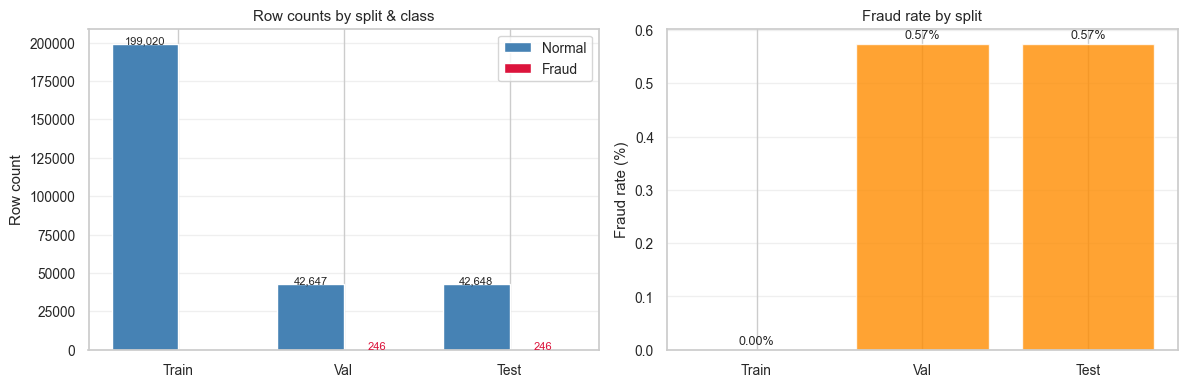

In [57]:
# ── Exact counts ─────────────────────────────────────────────────────────────
n_tr_normal = len(X_train)
n_va_normal = int((y_val  == 0).sum())
n_va_fraud  = int((y_val  == 1).sum())
n_te_normal = int((y_test == 0).sum())
n_te_fraud  = int((y_test == 1).sum())

summary = pd.DataFrame({
    "Split"       : ["Train",       "Val",         "Test",        "TOTAL"],
    "Normal"      : [n_tr_normal,   n_va_normal,   n_te_normal,   n_tr_normal + n_va_normal + n_te_normal],
    "Fraud"       : [0,             n_va_fraud,    n_te_fraud,    n_va_fraud + n_te_fraud],
    "Total rows"  : [n_tr_normal,   len(X_val),    len(X_test),   n_tr_normal + len(X_val) + len(X_test)],
    "Fraud rate"  : ["0.00%",
                     f"{y_val.mean()*100:.2f}%",
                     f"{y_test.mean()*100:.2f}%",
                     f"{(n_va_fraud+n_te_fraud)/(len(X_val)+len(X_test))*100:.2f}%"],
}).set_index("Split")

print(summary.to_string())

# ── Bar chart: rows per split coloured by class ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

splits  = ["Train", "Val", "Test"]
normals = [n_tr_normal, n_va_normal, n_te_normal]
frauds  = [0,           n_va_fraud,  n_te_fraud]
x = np.arange(len(splits))
w = 0.4

ax = axes[0]
ax.bar(x - w/2, normals, w, label="Normal", color="steelblue")
ax.bar(x + w/2, frauds,  w, label="Fraud",  color="crimson")
ax.set_xticks(x); ax.set_xticklabels(splits)
ax.set_ylabel("Row count")
ax.set_title("Row counts by split & class")
ax.legend(); ax.grid(axis="y", alpha=0.3)
for xi, n, fd in zip(x, normals, frauds):
    ax.text(xi - w/2, n + 200,  f"{n:,}",  ha="center", fontsize=8)
    if fd:
        ax.text(xi + w/2, fd + 200, f"{fd:,}", ha="center", fontsize=8, color="crimson")

ax = axes[1]
fraud_rates = [0, y_val.mean()*100, y_test.mean()*100]
colors = ["steelblue", "darkorange", "darkorange"]
bars = ax.bar(splits, fraud_rates, color=colors, alpha=0.8)
ax.set_ylabel("Fraud rate (%)")
ax.set_title("Fraud rate by split")
ax.grid(axis="y", alpha=0.3)
for bar, rate in zip(bars, fraud_rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{rate:.2f}%", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(FIG / "split_summary.png", dpi=150, bbox_inches="tight")
plt.show()

## C. Scaling Quality

Per-feature statistics after two-stage scaling (RobustScaler → StandardScaler → clip ±5).
Train mean ≈ 0 and std ∈ [0.5, 1.0] for all features. Std < 1 on heavy-tailed PCA features
is expected — clipping at ±5 truncates the tail mass.

Per-feature scaling statistics (all splits):
        train_mean  train_std  train_min  train_max  val_mean  val_std  test_mean  test_std
Time        0.0000     1.0000    -1.9965     1.6416   -0.0018   0.9974     0.0009    1.0018
V1          0.0088     0.9269    -5.0000     1.2681    0.0039   0.9426    -0.0046    0.9516
V2          0.0124     0.8655    -5.0000     5.0000    0.0179   0.8907     0.0221    0.8886
V3          0.0036     0.9723    -5.0000     5.0000   -0.0079   0.9965    -0.0223    1.0111
V4         -0.0005     0.9967    -4.0534     5.0000    0.0231   1.0191     0.0150    1.0270
V5          0.0013     0.9128    -5.0000     5.0000   -0.0066   0.9303    -0.0009    0.9326
V6         -0.0002     0.9763    -5.0000     5.0000   -0.0076   0.9819    -0.0008    0.9826
V7         -0.0017     0.8747    -5.0000     5.0000   -0.0238   0.9130    -0.0215    0.9078
V8          0.0188     0.7684    -5.0000     5.0000    0.0233   0.7758     0.0278    0.7861
V9         -0.0016     0.9902    -5

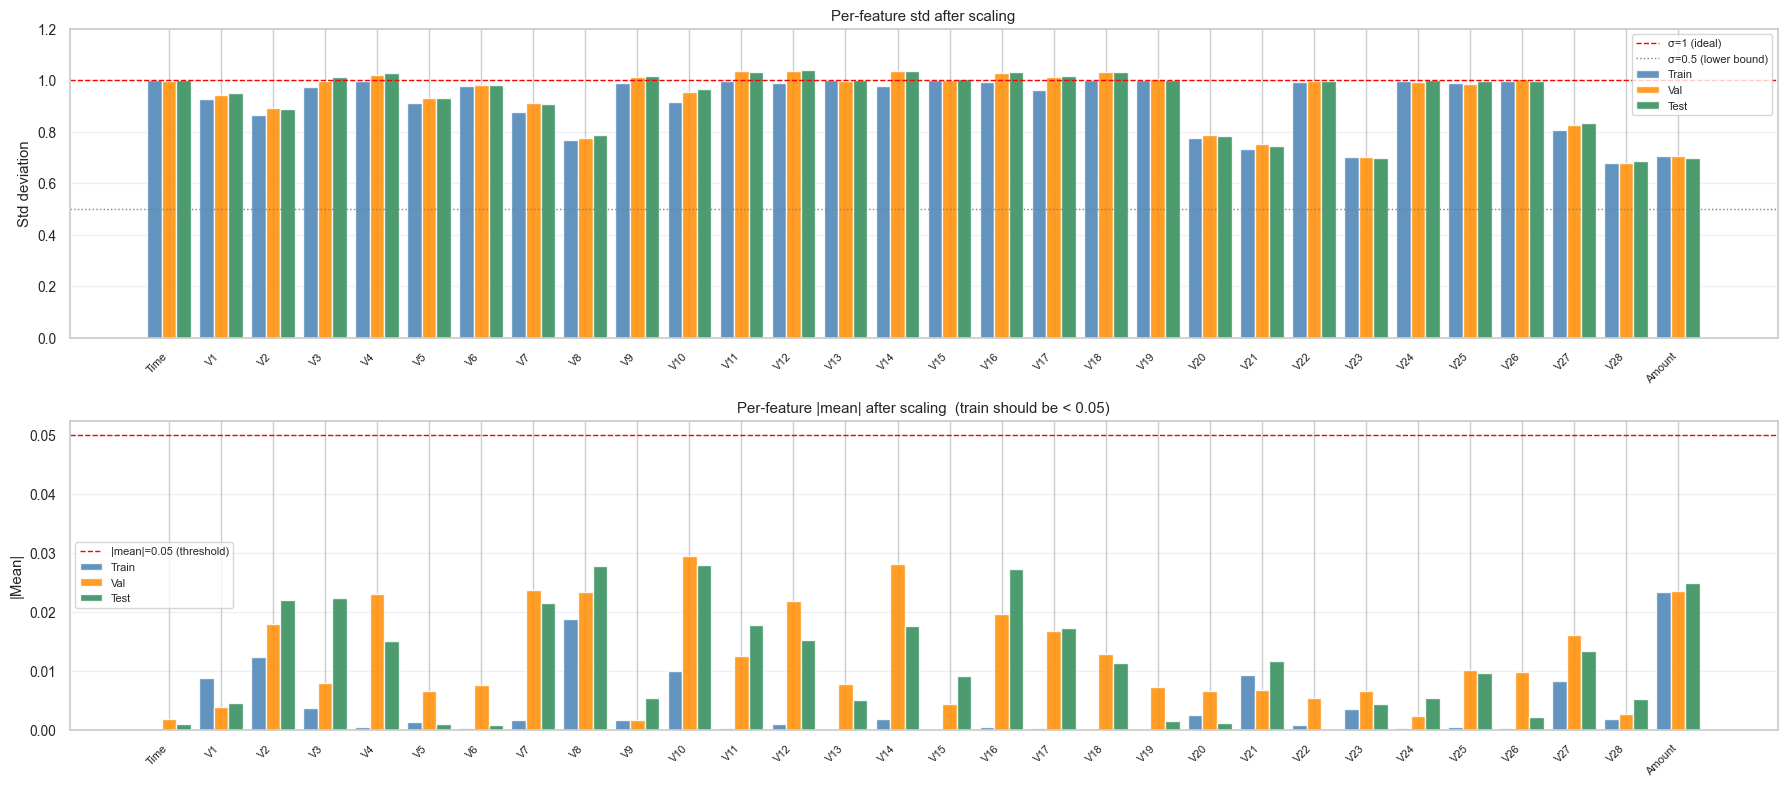

In [58]:
feat_stats = pd.DataFrame({
    "train_mean" : X_train.mean(axis=0),
    "train_std"  : X_train.std(axis=0),
    "train_min"  : X_train.min(axis=0),
    "train_max"  : X_train.max(axis=0),
    "val_mean"   : X_val.mean(axis=0),
    "val_std"    : X_val.std(axis=0),
    "test_mean"  : X_test.mean(axis=0),
    "test_std"   : X_test.std(axis=0),
}, index=features).round(4)

print("Per-feature scaling statistics (all splits):")
print(feat_stats.to_string())

# ── Std bar chart: all 30 features ───────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(18, 8))

x = np.arange(len(features))
w = 0.28

ax = axes[0]
ax.bar(x - w,   feat_stats["train_std"], w, label="Train", color="steelblue",  alpha=0.85)
ax.bar(x,       feat_stats["val_std"],   w, label="Val",   color="darkorange", alpha=0.85)
ax.bar(x + w,   feat_stats["test_std"],  w, label="Test",  color="seagreen",   alpha=0.85)
ax.axhline(1.0, color="red",  linestyle="--", linewidth=1, label="σ=1 (ideal)")
ax.axhline(0.5, color="grey", linestyle=":",  linewidth=1, label="σ=0.5 (lower bound)")
ax.set_xticks(x); ax.set_xticklabels(features, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Std deviation"); ax.set_title("Per-feature std after scaling")
ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3); ax.set_ylim(0, 1.2)

ax = axes[1]
ax.bar(x - w,   np.abs(feat_stats["train_mean"]), w, label="Train", color="steelblue",  alpha=0.85)
ax.bar(x,       np.abs(feat_stats["val_mean"]),   w, label="Val",   color="darkorange", alpha=0.85)
ax.bar(x + w,   np.abs(feat_stats["test_mean"]),  w, label="Test",  color="seagreen",   alpha=0.85)
ax.axhline(0.05, color="red", linestyle="--", linewidth=1, label="|mean|=0.05 (threshold)")
ax.set_xticks(x); ax.set_xticklabels(features, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("|Mean|"); ax.set_title("Per-feature |mean| after scaling  (train should be < 0.05)")
ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(FIG / "scaling_quality.png", dpi=150, bbox_inches="tight")
plt.show()

## D. Feature Distributions — Normal vs Fraud

Histograms for all 30 features in the **val set** (Normal vs Fraud).
Features with strong separation are the VAE's primary anomaly signal.

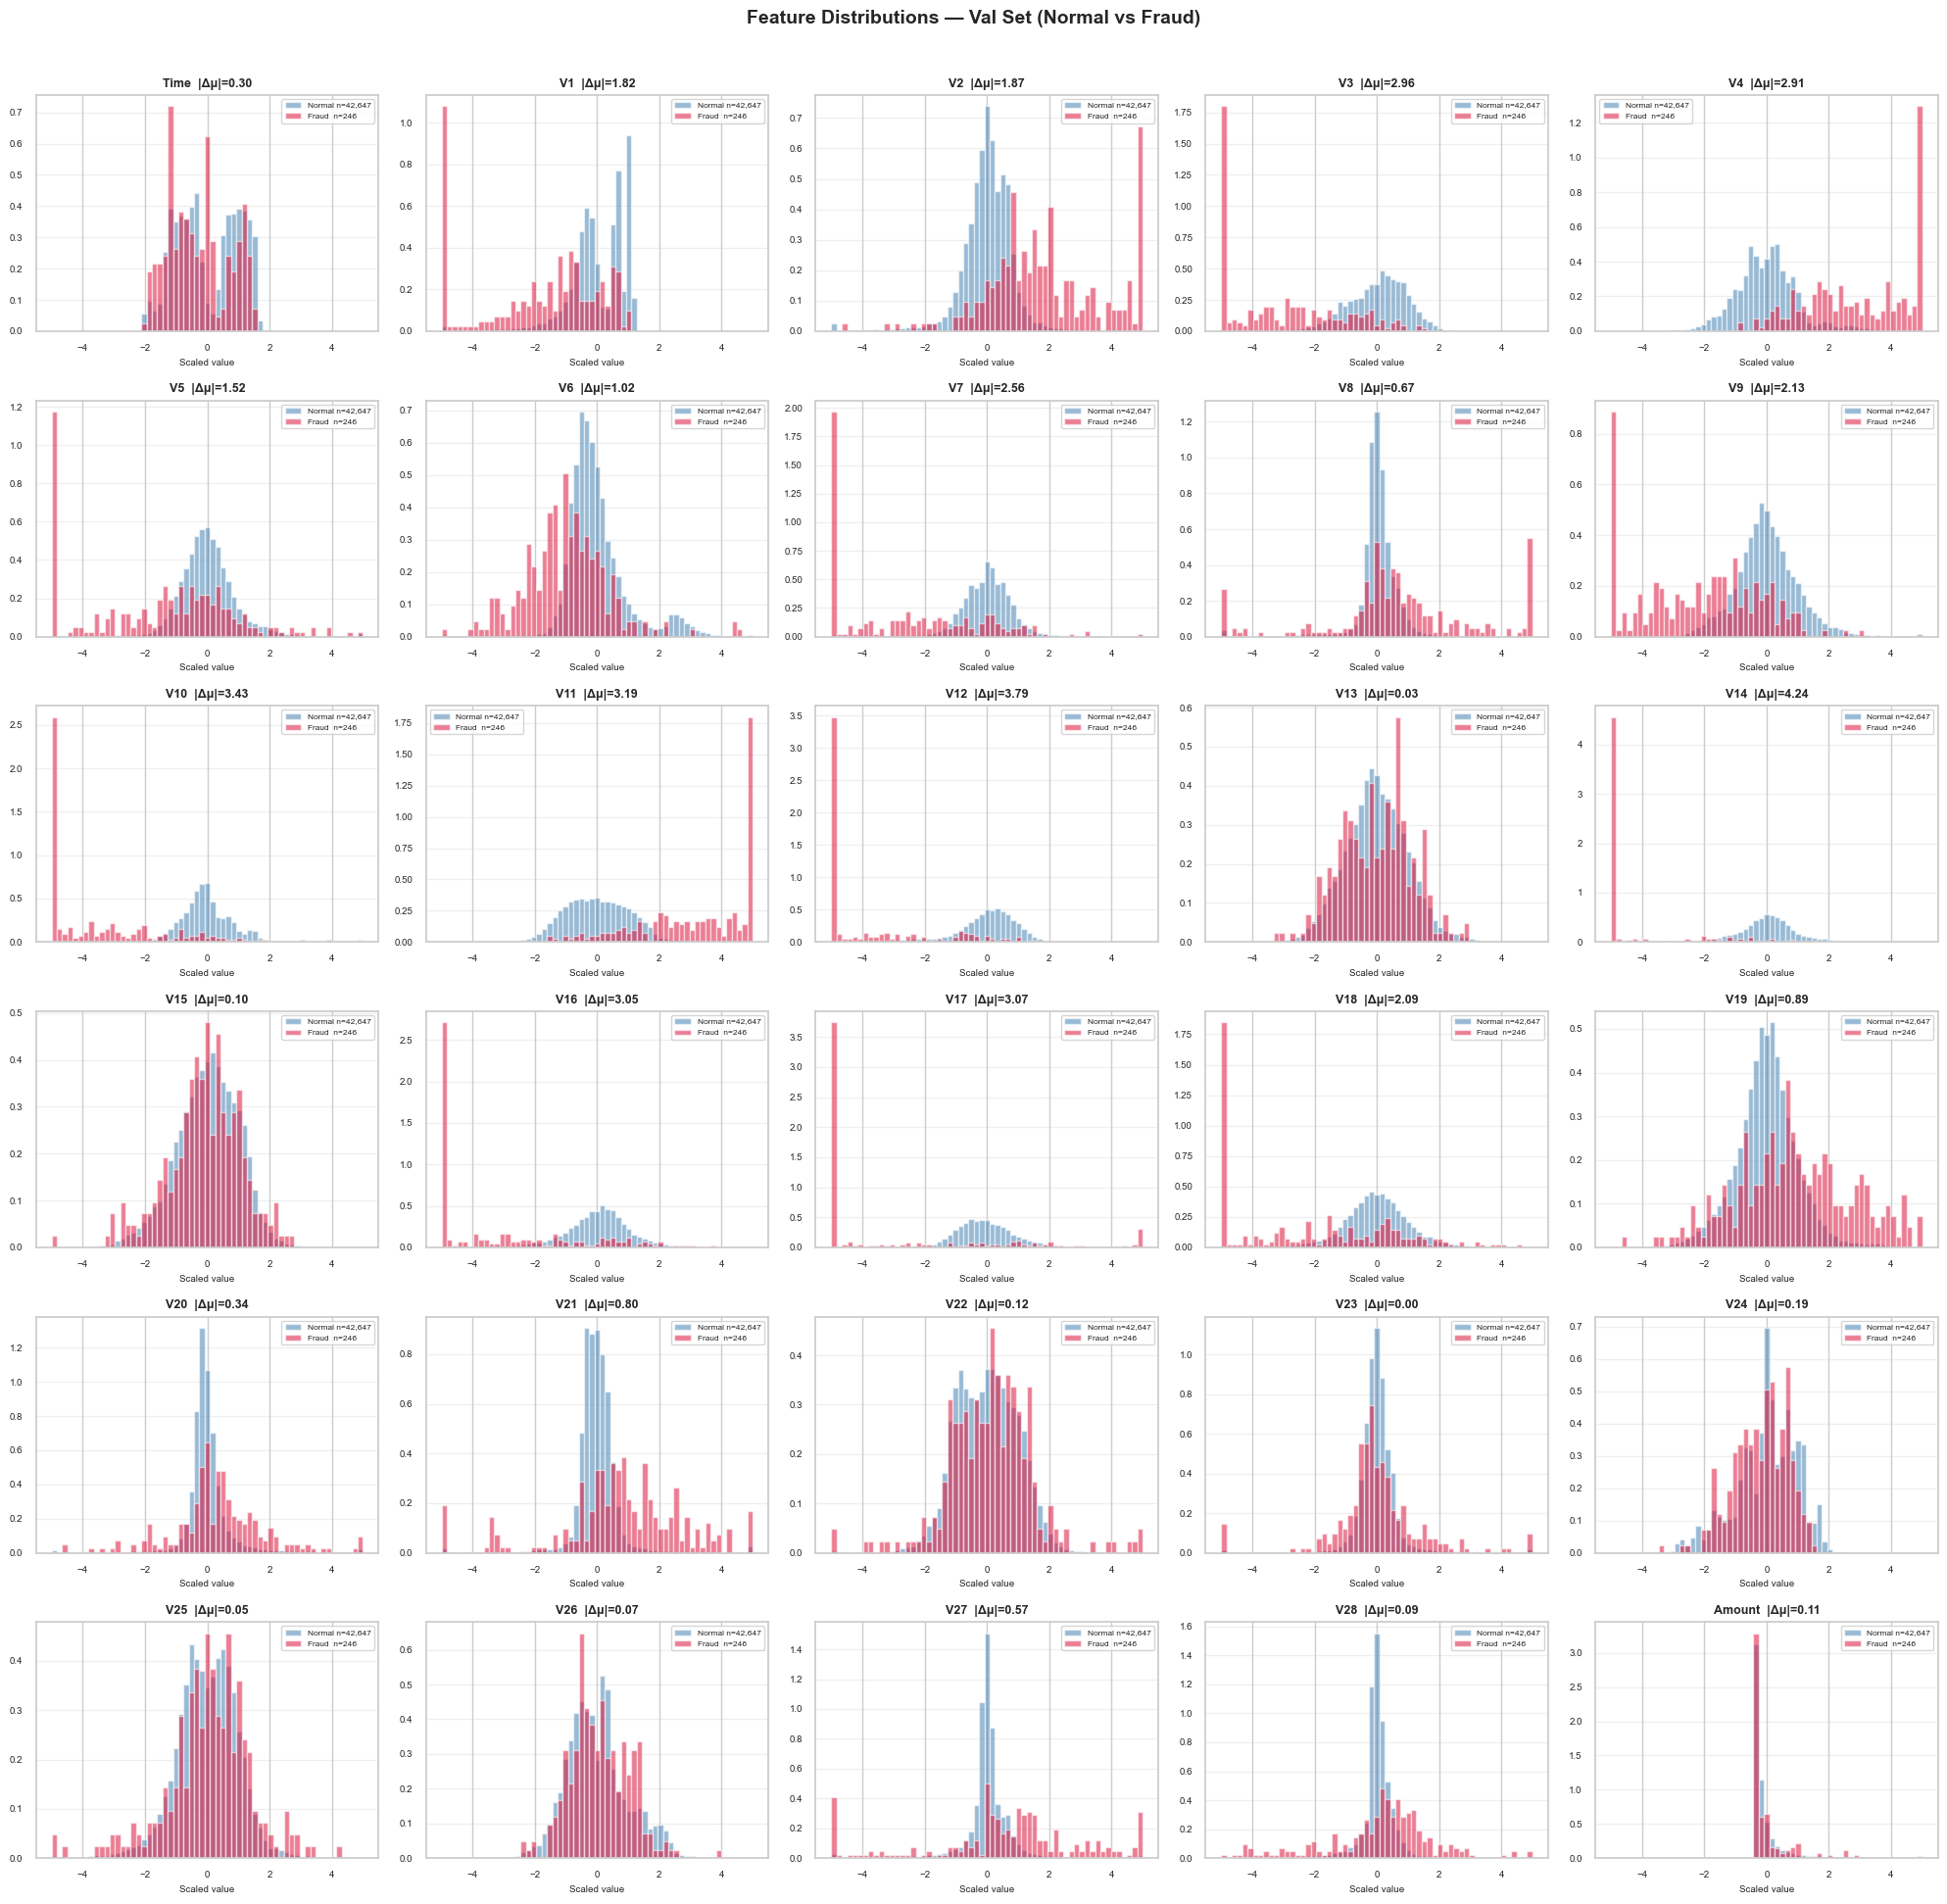

Saved → reports/figures/feature_distributions.png


In [59]:
normal_mask = y_val == 0
fraud_mask  = y_val == 1

n_cols = 5
n_rows = math.ceil(len(features) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3.2))
axes = axes.flatten()

clip  = 5.0
bins  = np.linspace(-clip, clip, 60)

for i, feat in enumerate(features):
    ax = axes[i]
    normal_vals = X_val[normal_mask, i]
    fraud_vals  = X_val[fraud_mask,  i]

    ax.hist(normal_vals, bins=bins, alpha=0.55, density=True,
            color="steelblue", label=f"Normal n={normal_mask.sum():,}")
    ax.hist(fraud_vals,  bins=bins, alpha=0.55, density=True,
            color="crimson",   label=f"Fraud  n={fraud_mask.sum():,}")

    # Annotate with mean difference
    delta = abs(fraud_vals.mean() - normal_vals.mean())
    ax.set_title(f"{feat}  |Δμ|={delta:.2f}", fontsize=9, fontweight="bold")
    ax.set_xlabel("Scaled value", fontsize=7)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=6)
    ax.grid(axis="y", alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle("Feature Distributions — Val Set (Normal vs Fraud)", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(FIG / "feature_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → reports/figures/feature_distributions.png")

## E. Top Discriminative Features

Ranked by |mean_fraud − mean_normal| on the val set.
These are the features where the VAE will produce the largest reconstruction error
for fraudulent transactions.

Feature ranking by |mean_fraud - mean_normal|  (val set):
        |Δ mean|  Normal mean  Normal std  Fraud mean  Fraud std
V14        4.240       -0.004       0.981      -4.243      1.642
V12        3.792       -0.000       0.989      -3.792      1.820
V10        3.431       -0.010       0.910      -3.441      1.928
V11        3.194       -0.006       1.002       3.189      1.775
V17        3.071        0.001       0.962      -3.070      3.108
V16        3.051       -0.002       0.990      -3.053      2.353
V3         2.957        0.009       0.964      -2.948      1.876
V4         2.915        0.006       0.990       2.921      1.658
V7         2.564       -0.009       0.878      -2.573      2.260
V9         2.129        0.011       0.993      -2.119      1.886
V18        2.092       -0.001       1.005      -2.093      2.575
V2         1.872        0.007       0.871       1.880      1.834
V1         1.821        0.014       0.924      -1.806      1.907
V5         1.520        0.002   

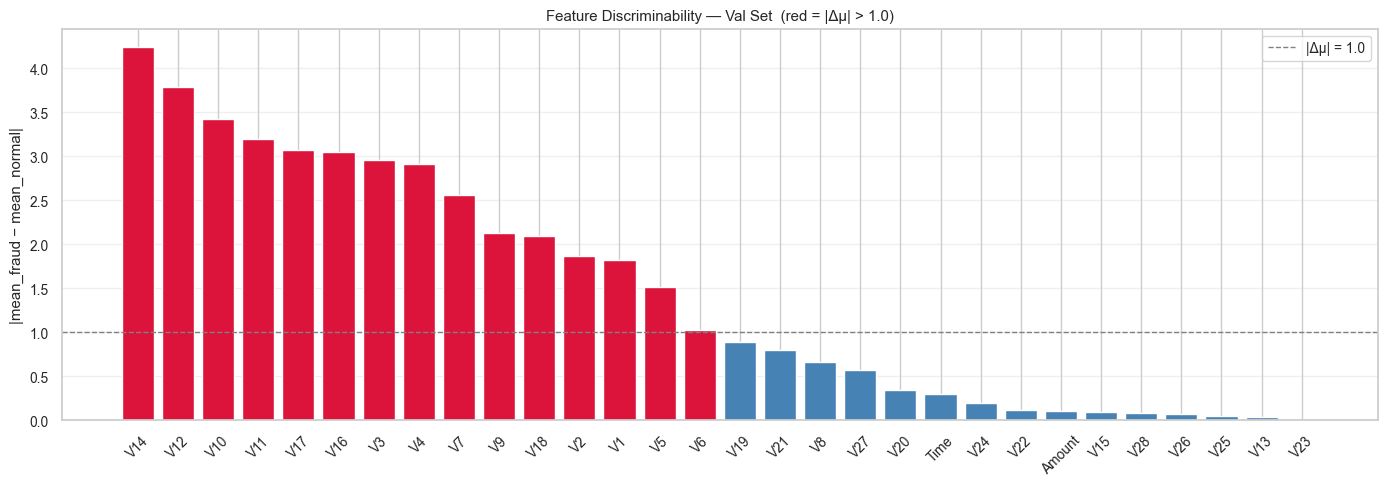

In [60]:
df_val = pd.DataFrame(X_val, columns=features)
df_val["label"] = y_val

group = df_val.groupby("label")[features].agg(["mean", "std"])
# group columns are MultiIndex: (feature, stat) — use .xs to slice by stat level
means = group.xs("mean", axis=1, level=1)   # shape: (2, 30)  index=[0, 1]
stds  = group.xs("std",  axis=1, level=1)

means.index = ["Normal", "Fraud"]
stds.index  = ["Normal", "Fraud"]

mean_diff = (means.loc["Fraud"] - means.loc["Normal"]).abs().sort_values(ascending=False)

ranking = pd.DataFrame({
    "|Δ mean|"    : mean_diff.values,
    "Normal mean" : means.loc["Normal"][mean_diff.index].values,
    "Normal std"  : stds.loc["Normal"][mean_diff.index].values,
    "Fraud mean"  : means.loc["Fraud"] [mean_diff.index].values,
    "Fraud std"   : stds.loc["Fraud"] [mean_diff.index].values,
}, index=mean_diff.index).round(3)

print("Feature ranking by |mean_fraud - mean_normal|  (val set):")
print(ranking.to_string())

# ── Bar chart ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
colors = ["crimson" if v > 1.0 else "steelblue" for v in mean_diff.values]
ax.bar(mean_diff.index, mean_diff.values, color=colors)
ax.axhline(1.0, color="grey", linestyle="--", linewidth=1, label="|Δμ| = 1.0")
ax.set_ylabel("|mean_fraud − mean_normal|")
ax.set_title("Feature Discriminability — Val Set  (red = |Δμ| > 1.0)")
ax.tick_params(axis="x", rotation=45)
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(FIG / "discriminative_features.png", dpi=150, bbox_inches="tight")
plt.show()

## F. Train / Val / Test Consistency

Checks that the **normal-class** distribution is stable across splits.
Large mean or std differences suggest a stratification bug or data leakage.
Val and test means should be close to zero (train mean = 0 by construction).

Normal-class distribution consistency across splits:
        train_mean  val_mean  test_mean  Δ mean (val-train)  Δ mean (test-train)  train_std  val_std  test_std  Δ std (val-train)  Δ std (test-train)
Time        0.0000   -0.0000     0.0026             -0.0000               0.0026     1.0000   0.9974    1.0012            -0.0026              0.0012
V1          0.0088    0.0143     0.0054              0.0055              -0.0035     0.9269   0.9240    0.9334            -0.0030              0.0065
V2          0.0124    0.0072     0.0113             -0.0053              -0.0012     0.8655   0.8709    0.8676             0.0055              0.0021
V3          0.0036    0.0090    -0.0039              0.0054              -0.0075     0.9723   0.9636    0.9750            -0.0087              0.0028
V4         -0.0005    0.0064    -0.0024              0.0069              -0.0019     0.9967   0.9900    0.9970            -0.0067              0.0003
V5          0.0013    0.0021     0.0080        

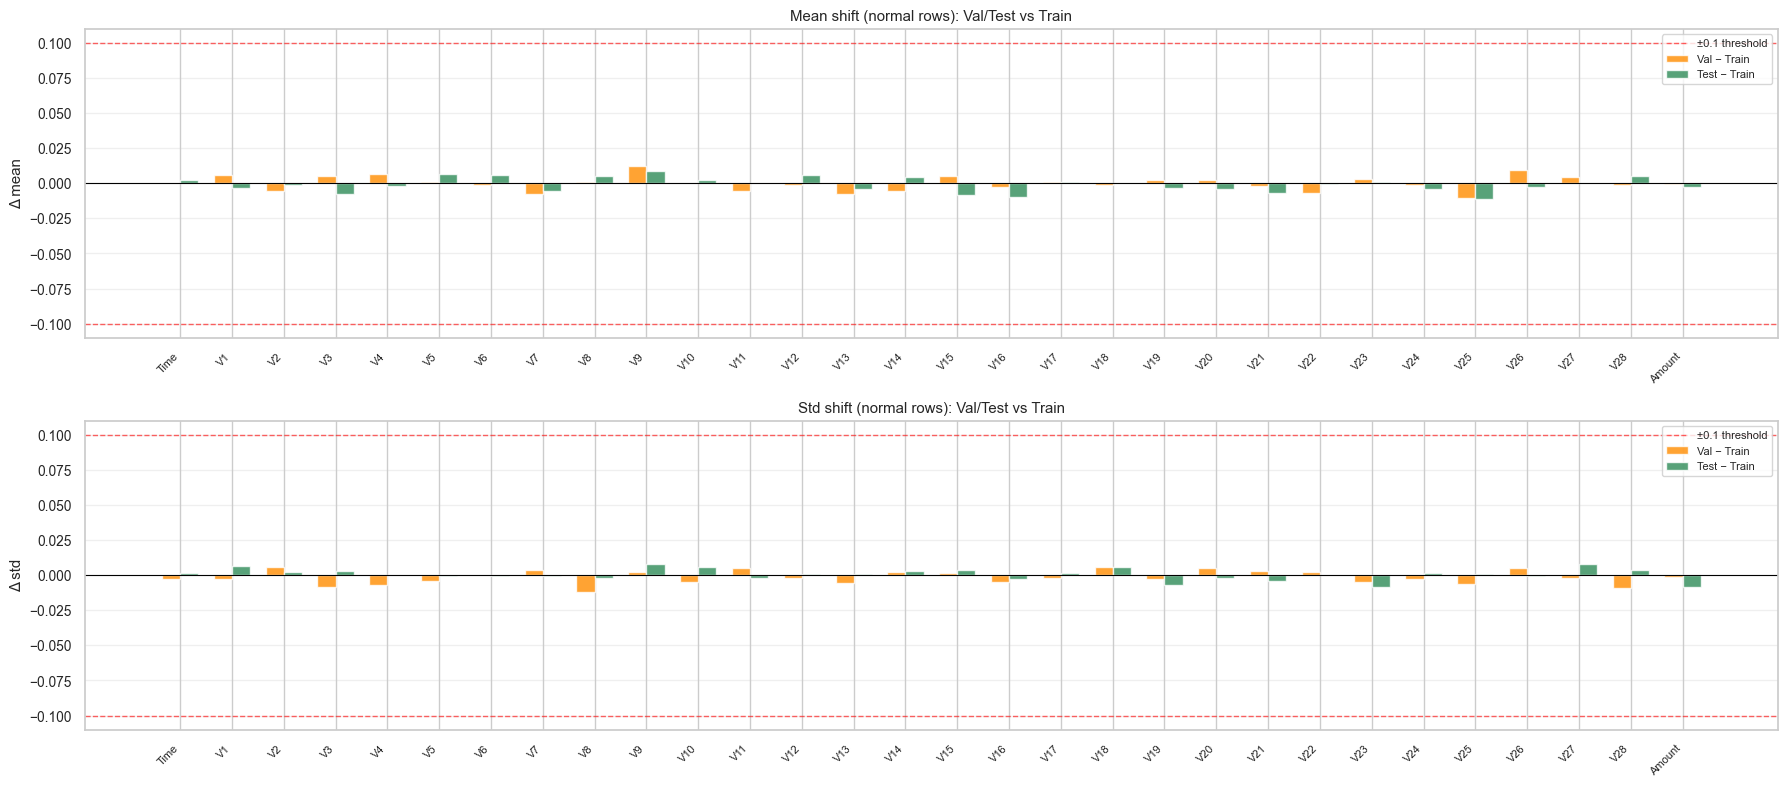

In [61]:
# Compare normal-class rows only across splits
normal_val  = X_val[y_val  == 0]
normal_test = X_test[y_test == 0]

tr_mean = X_train.mean(axis=0)
va_mean = normal_val.mean(axis=0)
te_mean = normal_test.mean(axis=0)
tr_std  = X_train.std(axis=0)
va_std  = normal_val.std(axis=0)
te_std  = normal_test.std(axis=0)

consistency = pd.DataFrame({
    "train_mean" : tr_mean,
    "val_mean"   : va_mean,
    "test_mean"  : te_mean,
    "Δ mean (val-train)"  : va_mean - tr_mean,
    "Δ mean (test-train)" : te_mean - tr_mean,
    "train_std"  : tr_std,
    "val_std"    : va_std,
    "test_std"   : te_std,
    "Δ std (val-train)"   : va_std - tr_std,
    "Δ std (test-train)"  : te_std - tr_std,
}, index=features).round(4)

print("Normal-class distribution consistency across splits:")
print(consistency.to_string())

max_mean_shift = max(
    np.abs(va_mean - tr_mean).max(),
    np.abs(te_mean - tr_mean).max(),
)
max_std_shift = max(
    np.abs(va_std - tr_std).max(),
    np.abs(te_std - tr_std).max(),
)
print(f"\nMax |Δ mean| across splits : {max_mean_shift:.4f}  (expect < 0.10)")
print(f"Max |Δ std|  across splits : {max_std_shift:.4f}  (expect < 0.10)")

# ── 2-panel plot: mean and std shifts ─────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(18, 8))
x = np.arange(len(features))
w = 0.35

ax = axes[0]
ax.bar(x - w/2, (va_mean - tr_mean), w, label="Val − Train", color="darkorange", alpha=0.8)
ax.bar(x + w/2, (te_mean - tr_mean), w, label="Test − Train", color="seagreen",   alpha=0.8)
ax.axhline(0,    color="black", linewidth=0.8)
ax.axhline( 0.1, color="red", linestyle="--", linewidth=1, alpha=0.6)
ax.axhline(-0.1, color="red", linestyle="--", linewidth=1, alpha=0.6, label="±0.1 threshold")
ax.set_xticks(x); ax.set_xticklabels(features, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Δ mean"); ax.set_title("Mean shift (normal rows): Val/Test vs Train")
ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)

ax = axes[1]
ax.bar(x - w/2, (va_std - tr_std), w, label="Val − Train", color="darkorange", alpha=0.8)
ax.bar(x + w/2, (te_std - tr_std), w, label="Test − Train", color="seagreen",   alpha=0.8)
ax.axhline(0,    color="black", linewidth=0.8)
ax.axhline( 0.1, color="red", linestyle="--", linewidth=1, alpha=0.6)
ax.axhline(-0.1, color="red", linestyle="--", linewidth=1, alpha=0.6, label="±0.1 threshold")
ax.set_xticks(x); ax.set_xticklabels(features, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Δ std"); ax.set_title("Std shift (normal rows): Val/Test vs Train")
ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(FIG / "split_consistency.png", dpi=150, bbox_inches="tight")
plt.show()

## D2. Box Plots — Top 10 Discriminative Features

Compact view of spread and outlier mass for the 10 most separating features.

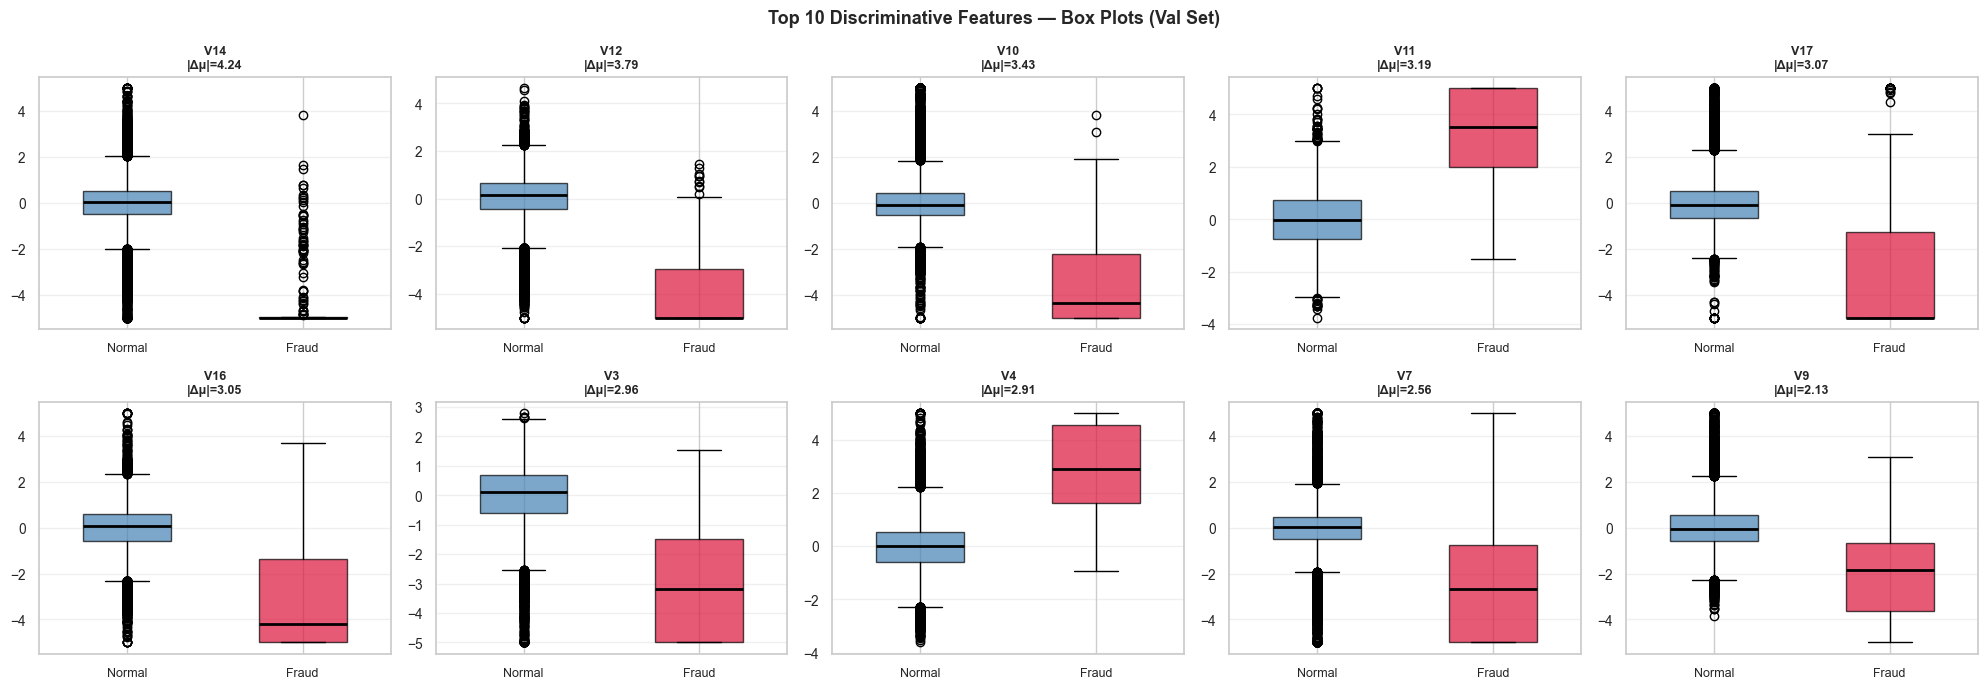

In [62]:
# Reuse mean_diff ranking from section E
top10 = mean_diff.head(10).index.tolist()

fig, axes = plt.subplots(2, 5, figsize=(20, 7))
axes = axes.flatten()

for i, feat in enumerate(top10):
    ax = axes[i]
    feat_idx = features.index(feat)
    data = [X_val[y_val == 0, feat_idx], X_val[y_val == 1, feat_idx]]
    bp = ax.boxplot(data, patch_artist=True, notch=False,
                    medianprops=dict(color="black", linewidth=2),
                    widths=0.5)
    bp["boxes"][0].set_facecolor("steelblue")
    bp["boxes"][0].set_alpha(0.7)
    bp["boxes"][1].set_facecolor("crimson")
    bp["boxes"][1].set_alpha(0.7)
    ax.set_xticklabels(["Normal", "Fraud"], fontsize=9)
    ax.set_title(f"{feat}\n|Δμ|={mean_diff[feat]:.2f}", fontsize=9, fontweight="bold")
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Top 10 Discriminative Features — Box Plots (Val Set)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG / "top10_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

## G. Correlation Matrix

Pearson correlations among all 30 features in the **training set** (normal class only).
V1-V28 are PCA components so they are orthogonal by construction — expect near-zero
off-diagonal values. Strong correlation involving Time or Amount is worth noting.

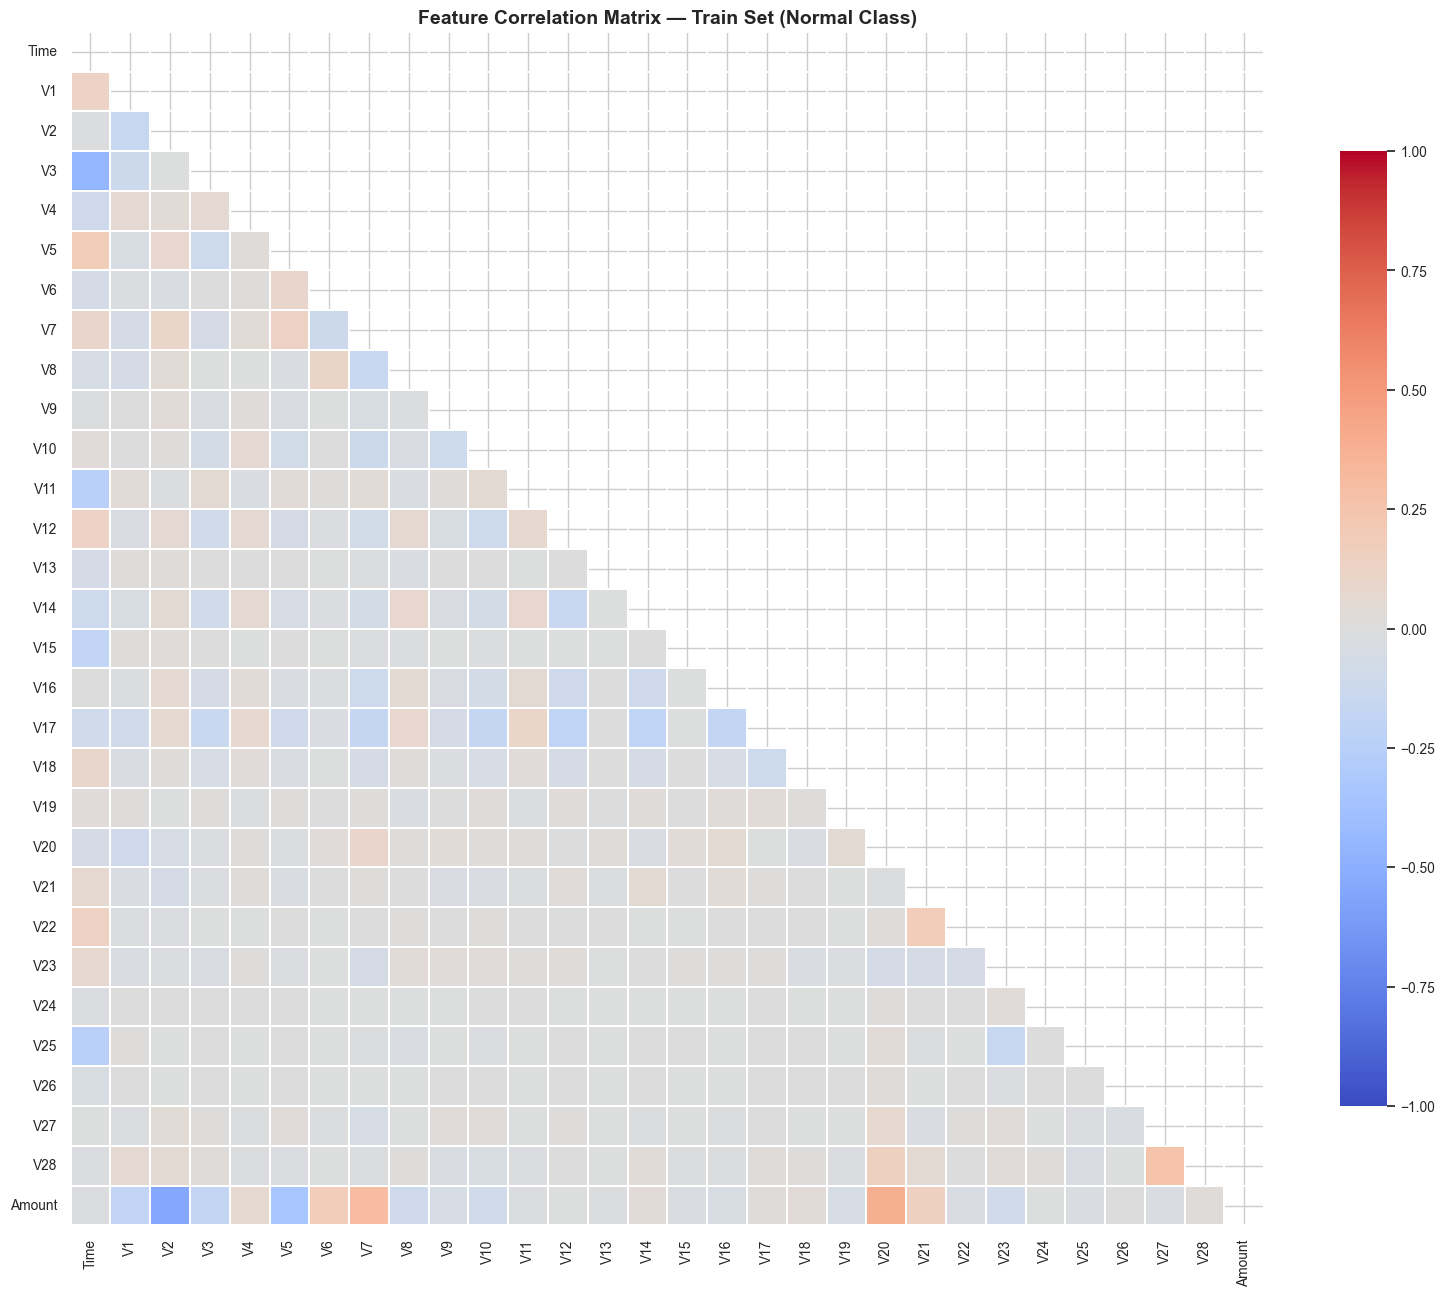

High correlations |r| > 0.3:
Amount  V2        0.543
V3      Time      0.454
V20     Amount    0.386
V5      Amount    0.350
Amount  V7        0.309


In [63]:
corr = pd.DataFrame(X_train, columns=features).corr()

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask,
    annot=False, cmap="coolwarm",
    vmin=-1, vmax=1, center=0,
    square=True, linewidths=0.3,
    cbar_kws={"shrink": 0.8},
    ax=ax,
)
ax.set_title("Feature Correlation Matrix — Train Set (Normal Class)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG / "correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

# Flag high correlations (|r| > 0.3) excluding self
corr_vals = corr.abs().unstack()
corr_vals = corr_vals[corr_vals < 1.0].sort_values(ascending=False)
high_corr = corr_vals[corr_vals > 0.3].drop_duplicates()
if len(high_corr):
    print(f"High correlations |r| > 0.3:")
    print(high_corr.head(10).round(3).to_string())
else:
    print("No feature pairs with |r| > 0.3 — PCA orthogonality confirmed.")

## Summary

| Figure | File |
|--------|------|
| Split row counts & fraud rates | `reports/figures/split_summary.png` |
| Per-feature mean & std by split | `reports/figures/scaling_quality.png` |
| Feature histograms (Normal vs Fraud) | `reports/figures/feature_distributions.png` |
| Discriminative feature ranking | `reports/figures/discriminative_features.png` |
| Distribution shift across splits | `reports/figures/split_consistency.png` |
| Top-10 box plots | `reports/figures/top10_boxplots.png` |
| Correlation matrix | `reports/figures/correlation_matrix.png` |

**Ready to train if all Section A checks passed.**